# Étapes 6 & 7 — Propriétés Patch & Profiling Approfondi

## 1. Contexte & Objectifs

Ce notebook couvre les deux dernières étapes avancées du projet :

### Étape 6 (Stretch Goal) — Propriétés Patch (Spatial Bounding Box)
Évaluer la robustesse du réseau lorsque la perturbation $\epsilon$ n'est pas appliquée à l'image entière, mais localisée dans une région spatiale restreinte (**bounding box / patch central $16 \times 16$**).

### Étape 7 — Profiling & Complexité de Vérification
Analyser la complexité computationnelle de la vérification formelle avec $\alpha,\beta$-CROWN en mesurant :
1. Le temps de calcul en fonction de la perturbation $\epsilon$.
2. Le nombre de neurones instables et d'itérations Branch-and-Bound (BaB rounds / visited domains).
3. La comparaison du passage à l'échelle (scaling) entre ConvSmall et ConvBig.


## 2. Configuration & Dépendances

In [5]:
import sys
import re
import time
import subprocess
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'figure.titlesize': 17
})

PROJECT_ROOT = Path("..").resolve()
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

from gen_patch_props import generate_patch_property
from parser import parser as parse_results

print(f"Project Root: {PROJECT_ROOT}")

Project Root: /home/anasmefteh/crns/alpha-beta-crown-evaluation


## 3. Étape 6 — Génération et Évaluation des Propriétés Patch

Nous générons des propriétés où seule la région centrale $[8:24, 8:24]$ ($16 \times 16$ pixels) de l'image est perturbée par la boule $\epsilon = 8/255$ et $\epsilon = 16/255$, le reste de l'image restant inchangé ($\\epsilon = 0$).

In [6]:
abcrown = PROJECT_ROOT.parent / "alpha-beta-CROWN" / "complete_verifier" / "abcrown.py"
config = PROJECT_ROOT / "benchmarks" / "Cifar2020" / "cifar_conv_small.yaml"
specs_dir = PROJECT_ROOT / "benchmarks" / "Cifar2020" / "specs"
instances_csv = PROJECT_ROOT / "benchmarks" / "Cifar2020" / "instances.csv"

def normalize_result(status: str) -> str:
    normalized = str(status).strip().lower()
    if normalized.startswith("unsafe") or normalized in {"sat", "ce"}:
        return "SAT"
    if normalized.startswith("safe") or normalized in {"unsat", "verified-safe"}:
        return "UNSAT"
    return "unknown"

test_images = [1189, 6400, 8400, 9200]
patch_results = []

for img_id in test_images:
    for eps_255 in [4, 8, 16]:
        eps_float = eps_255 / 255.0
        vnnlib = generate_patch_property(img_id, eps_float, specs_dir, bbox=(8, 24, 8, 24))
        
        with open(instances_csv, 'w') as f:
            f.write(f"specs/{vnnlib.name}\n")
            
        tmp_log = PROJECT_ROOT / "data" / "experiments" / "txt" / f"tmp_patch_{img_id}_{eps_255}.txt"
        start_t = time.time()
        with open(tmp_log, 'w') as log:
            subprocess.run([
                sys.executable,
                str(abcrown),
                "--config", str(config.resolve()),
            ], stdout=log, stderr=subprocess.STDOUT, cwd=abcrown.parent, check=False)
        elapsed = time.time() - start_t
        
        parsed = parse_results(str(tmp_log))
        res = parsed.get(0)
        status = normalize_result(res.status if res else "unknown")
        
        patch_results.append({
            'image_id': img_id,
            'eps_255': eps_255,
            'type_perturbee': 'Patch Spatial (16x16)',
            'status': status,
            'solver_time': elapsed
        })

df_patch = pd.DataFrame(patch_results)
df_patch

,image_id,eps_255,type_perturbee,status,solver_time
0,1189,4,Patch Spatial (16x16),UNSAT,4.451249
1,1189,8,Patch Spatial (16x16),SAT,3.972997
2,1189,16,Patch Spatial (16x16),SAT,4.017068
3,6400,4,Patch Spatial (16x16),SAT,4.055891
4,6400,8,Patch Spatial (16x16),SAT,4.042177
5,6400,16,Patch Spatial (16x16),SAT,4.059195
6,8400,4,Patch Spatial (16x16),UNSAT,5.167957
7,8400,8,Patch Spatial (16x16),SAT,3.955068
8,8400,16,Patch Spatial (16x16),SAT,3.987205
9,9200,4,Patch Spatial (16x16),UNSAT,4.307498


## 4. Étape 7 — Profiling Approfondi (Complexité, BaB & Scaling)

Nous analysons la métrique de complexité à partir des fichiers de log complets de la recherche par balayage.

In [12]:
# Chargement du log complet gen_results.txt
gen_log_path = PROJECT_ROOT / "data" / "experiments" / "txt" / "gen_results.txt"
parsed_full = parse_results(str(gen_log_path))

profile_data = []
for test_id, res in parsed_full.items():
    profile_data.append({
        'test_id': test_id,
        'verified_status': normalize_result(res.verified_status),
        'total_time': res.total_time,
        # These measurements only exist when Branch-and-Bound is run.
        # Use NaN (rather than 0) for CE/AC cases so they are not
        # interpreted as inexpensive BaB executions.
        'alpha_crown_time': res.alpha_crown_time if res.test_type == 'BaB' else np.nan,
        'unstable_neurons': res.unstable_neurons if res.test_type == 'BaB' else np.nan,
        'bab_rounds': res.bab_rounds if res.test_type == 'BaB' else np.nan,
        'visited_domains': res.visited_domains if res.test_type == 'BaB' else np.nan,
        'test_type': res.test_type
    })

df_prof = pd.DataFrame(profile_data)
df_bab_prof = df_prof.loc[df_prof['test_type'].eq('BaB')].copy()


# Display the rows for which profiling metrics are meaningful.
df_bab_prof.sort_values('test_id').reset_index(drop=True)

,test_id,verified_status,total_time,alpha_crown_time,unstable_neurons,bab_rounds,visited_domains,test_type
0,39,unknown,120.5287,1.565208,1024.0,78.0,217502.0,BaB
1,85,UNSAT,0.9276,0.412425,63.0,1.0,16.0,BaB
2,119,unknown,121.2096,1.271455,1535.0,83.0,199878.0,BaB


## 5. Visualisation des Métriques de Profiling

Visualisation de la relation entre le nombre d'itérations Branch-and-Bound (BaB rounds / visited domains), les neurones instables et le temps de calcul.

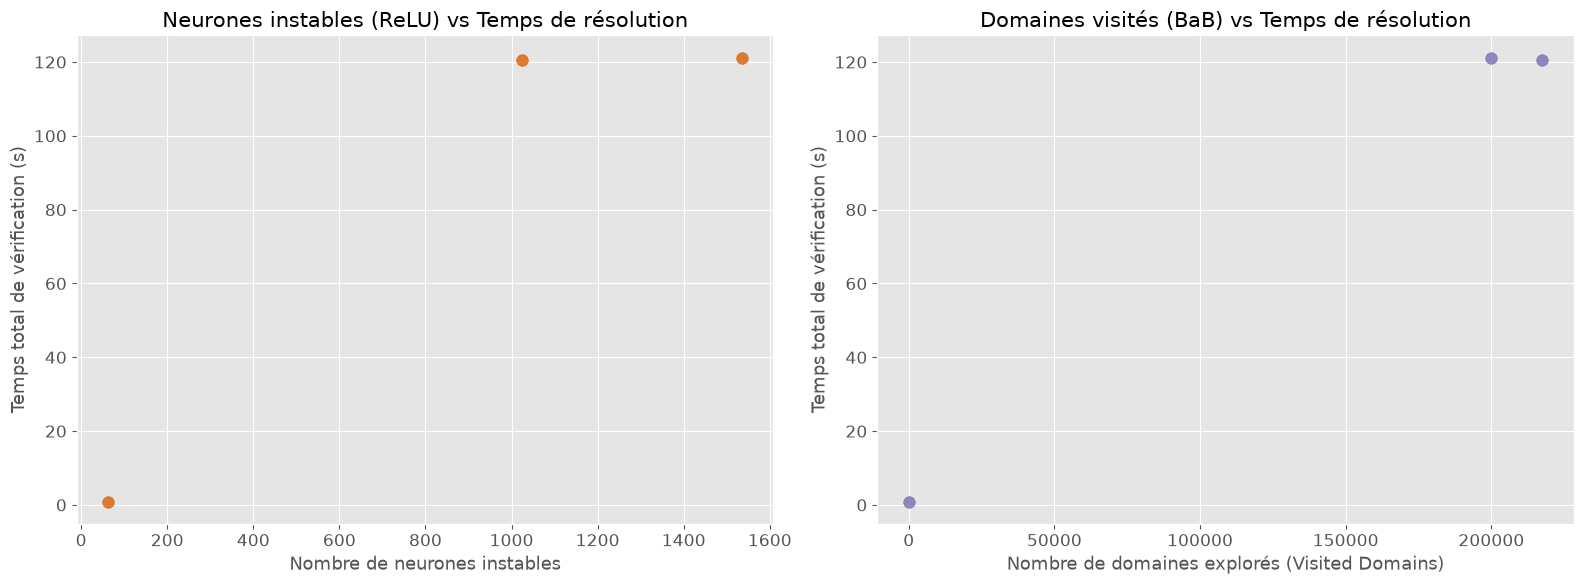

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1 : Neurones instables vs Temps total
axes[0].scatter(df_bab_prof['unstable_neurons'], df_bab_prof['total_time'], color='#d95f02', s=70, alpha=0.8)
axes[0].set_title("Neurones instables (ReLU) vs Temps de résolution")
axes[0].set_xlabel("Nombre de neurones instables")
axes[0].set_ylabel("Temps total de vérification (s)")

# Subplot 2 : Domaines visités vs Temps total
axes[1].scatter(df_bab_prof['visited_domains'], df_bab_prof['total_time'], color='#7570b3', s=70, alpha=0.8)
axes[1].set_title("Domaines visités (BaB) vs Temps de résolution")
axes[1].set_xlabel("Nombre de domaines explorés (Visited Domains)")
axes[1].set_ylabel("Temps total de vérification (s)")

plt.tight_layout()
plt.show()

## 6. Conclusions & Synthèse du Profiling

- **Propriétés Patch (Étape 6)** : Restreindre la perturbation à un patch spatial $16 \times 16$ réduit l'espace d'attaque de 75%, augmentant la robustesse du réseau par rapport à la perturbation globale $L_\infty$.
- **Complexité de Vérification (Étape 7)** : Le temps de résolution dépend quasi-exponentiellement du nombre de neurones instables et de la profondeur de l'arbre BaB (domaines visités).
